In [7]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from rich import print
import numpy as np
import matplotlib.pyplot as plt
import jax
print(jax.devices())

from pymcsimmod.parser import ModelParser

from pymcsimmod import create_model, JaxModel, ScipyModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[CpuDevice(id=0)]

In [2]:
filename = Path("../../tests/data/pk1_dosing.model")
assert filename.exists()
print(filename.absolute().resolve())

/data/tzurlind/Desktop/PKWG/PyMCSimMod/tests/data/pk1_dosing.model

In [3]:
parser = ModelParser()
parsed_model = parser.parse(filename.read_text())

## Using the Unified Model Interface

The refactored package provides a unified `create_model()` function that allows you to create models with different backends:

In [5]:
# Method 1: Using the unified interface (recommended)
scipy_model_unified = create_model(filename, backend="scipy")
jax_model_unified = create_model(filename, backend="jax")

print(f"Scipy model type: {type(scipy_model_unified)}")
print(f"JAX model type: {type(jax_model_unified)}")

# Method 2: Direct instantiation (backward compatibility maintained)
scipy_model_direct = ScipyModel(filename)
jax_model_direct = JaxModel(filename)

Scipy model type: <class 'pymcsimmod.models.scipy_model.ScipyModel'>

JAX model type: <class 'pymcsimmod.models.jax_model.JaxModel'>

# Scipy model

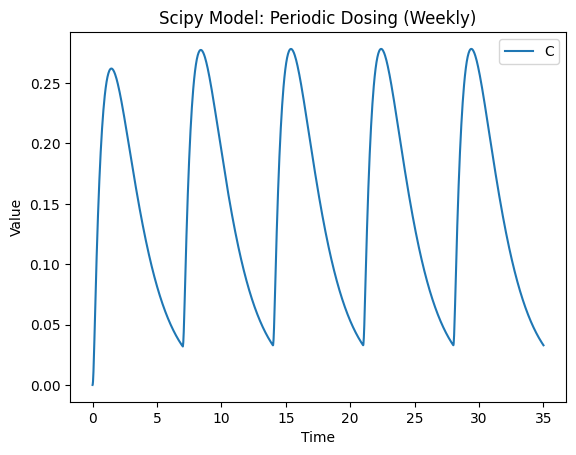

CPU times: user 259 ms, sys: 8.28 ms, total: 267 ms
Wall time: 267 ms


In [ ]:
%%time
# Example 1: Periodic dosing every 7 days with scipy model
scipy_model = ScipyModel(model=filename)
scipy_model.update_constants(OralDose=50)
scipy_model.assign_forcing_function(
    'OralExp', 
    'PerDose', 
    t0=0, 
    duration=scipy_model.parameters['OralDur'], 
    period=7,
    s=10.0  # Custom smoothing parameter (default is 10.0)
)

times = np.linspace(0, 35, 1000)
solution = scipy_model.run_model(times)
solution.plot_results(variables='C')
plt.title('Scipy Model: Periodic Dosing (Weekly)')
plt.show()

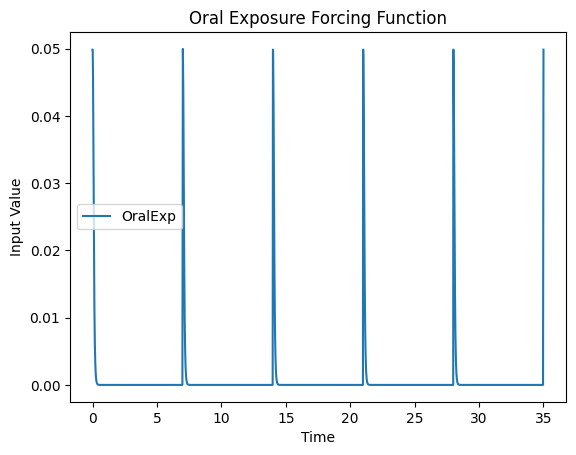

In [12]:
# Plot the forcing function input
solution.plot_inputs(variables='OralExp')
plt.title('Oral Exposure Forcing Function')
plt.show()

# JAX Model Examples

JAX models provide fast compilation and execution but have some limitations (e.g., no discrete events).

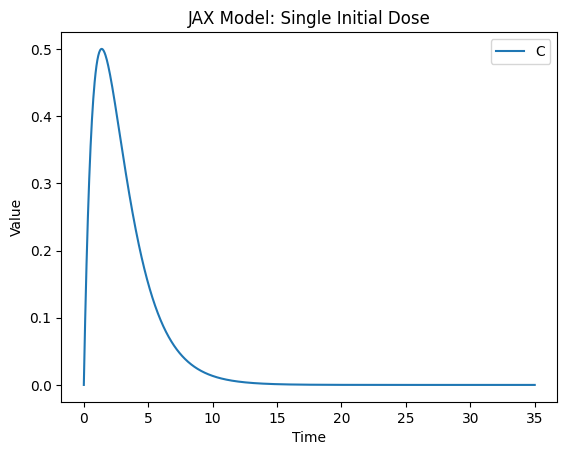

CPU times: user 1.29 s, sys: 211 ms, total: 1.5 s
Wall time: 1.12 s


In [13]:
%%time
# Example 1: Simple JAX model without forcing functions
jax_model = JaxModel(model=filename)
jax_model.update_Y0(A0=50.0)  # Initial dose
times = np.linspace(0, 35, 1000)
solution = jax_model.run_model(times)
solution.plot_results(variables='C')
plt.title('JAX Model: Single Initial Dose')
plt.show()

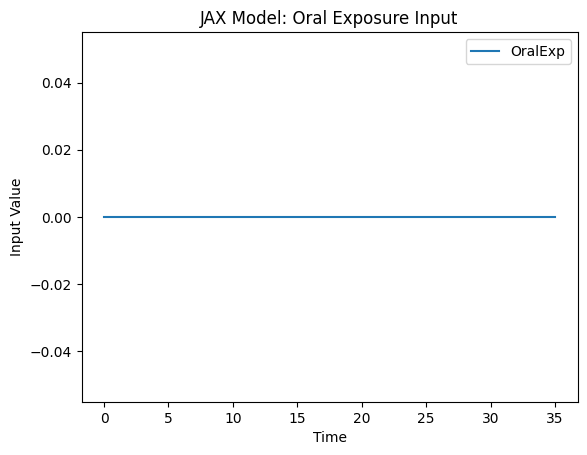

In [14]:
# Plot inputs for JAX model
solution.plot_inputs(variables='OralExp')
plt.title('JAX Model: Oral Exposure Input')
plt.show()

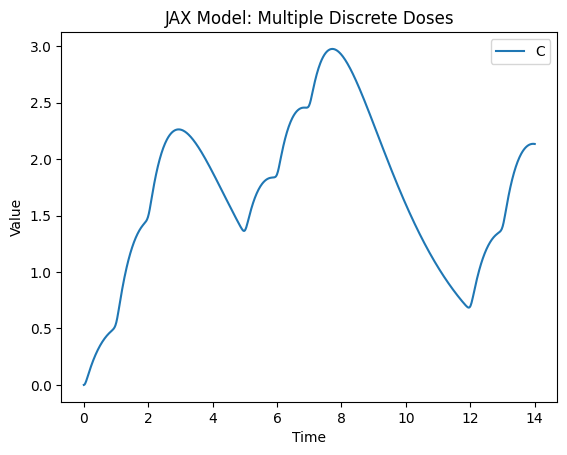

CPU times: user 1.12 s, sys: 90.5 ms, total: 1.21 s
Wall time: 895 ms


In [15]:
%%time
# Example 2: JAX model with multiple discrete doses
jax_model_doses = create_model(filename, backend="jax")
jax_model_doses.update_constants(OralDose=100)
jax_model_doses.assign_forcing_function(
    'OralExp', 
    'NDoses', 
    t0_list=[0, 1, 2, 5, 6, 7, 12, 13], 
    duration=jax_model_doses.parameters['OralDur'],
    s=15.0  # Custom smoothing parameter
)

times = np.linspace(0, 14, 1000)
solution = jax_model_doses.run_model(times)
solution.plot_results(variables='C')
plt.title('JAX Model: Multiple Discrete Doses')
plt.show()

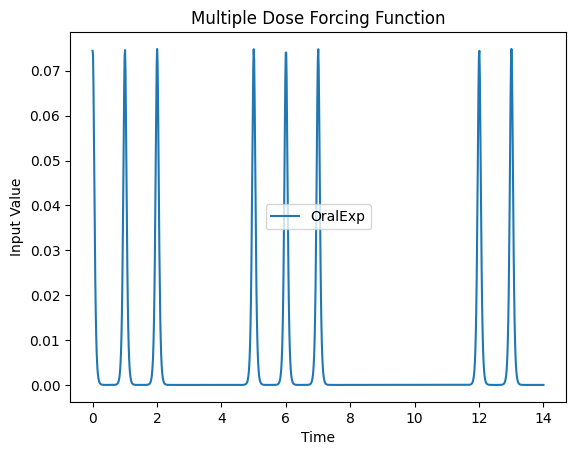

In [16]:
# Plot the multiple dose forcing function
solution.plot_inputs(variables='OralExp')
plt.title('Multiple Dose Forcing Function')
plt.show()

In [17]:
# Check the oral duration parameter
print(f"Oral duration parameter: {jax_model_doses.parameters['OralDur']}")

Oral duration parameter: 0.01

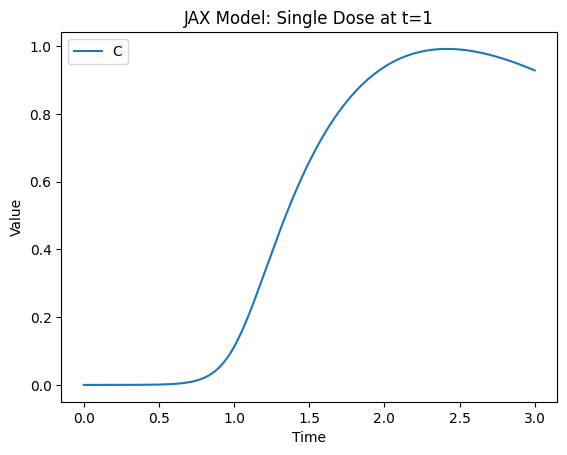

CPU times: user 1.07 s, sys: 107 ms, total: 1.18 s
Wall time: 886 ms


In [18]:
%%time
# Example 3: JAX model with single dose at specific time
jax_model_single = create_model(filename, backend="jax")
jax_model_single.update_constants(OralDose=100)
jax_model_single.assign_forcing_function(
    'OralExp', 
    'NDoses', 
    t0_list=[1], 
    duration=jax_model_single.parameters['OralDur'],
    s=5.0  # Sharper transition with lower smoothing
)

times = np.linspace(0, 3, 1000)
solution = jax_model_single.run_model(times)
solution.plot_results(variables='C')
plt.title('JAX Model: Single Dose at t=1')
plt.show()

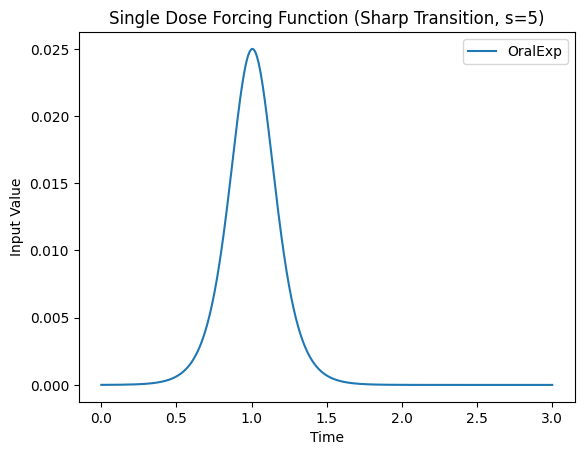

In [19]:
# Plot single dose forcing function
solution.plot_inputs(variables='OralExp')
plt.title('Single Dose Forcing Function (Sharp Transition, s=5)')
plt.show()

# Discrete Events Example

This demonstrates the new discrete events functionality similar to deSolve's event handling.
The discrete events system allows you to:
- **Add** to a state variable at specific times
- **Replace** a state variable value at specific times  
- **Multiply** a state variable by a factor at specific times

This is useful for modeling things like:
- Additional drug doses at specific times
- Bolus injections
- Sudden changes in system state
- Discrete interventions

**Note**: Discrete events are currently only supported in `ScipyModel`, not `JaxModel`.

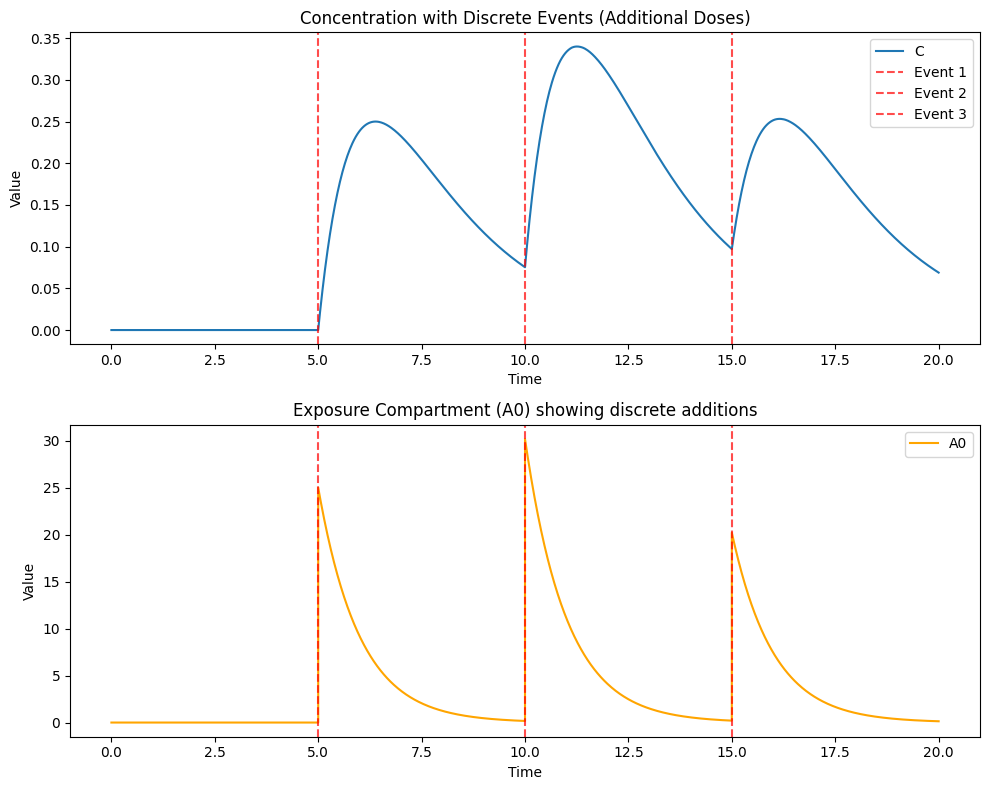

In [20]:
# Example 1: Adding additional doses using discrete events
# This shows how to add discrete "add" events for additional dosing

# Create a new ScipyModel instance
scipy_model_events = ScipyModel(model=filename)
scipy_model_events.update_constants(OralDose=50, OralDur=0.1)

# Add discrete events - additional doses at specific times
# Each event adds 25 mg to the A0 compartment (exposure compartment)
scipy_model_events.add_event(time=5.0, state_var='A0', value=25.0, method='add')  # Dose at t=5
scipy_model_events.add_event(time=10.0, state_var='A0', value=30.0, method='add') # Dose at t=10  
scipy_model_events.add_event(time=15.0, state_var='A0', value=20.0, method='add') # Dose at t=15

# Run the model
times = np.linspace(0, 20, 1000)
solution_events = scipy_model_events.run_model(times)

# Plot the results
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot concentration
solution_events.plot_results(variables='C', ax=ax1)
ax1.set_title('Concentration with Discrete Events (Additional Doses)')
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Event 1')
ax1.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='Event 2')
ax1.axvline(x=15, color='red', linestyle='--', alpha=0.7, label='Event 3')
ax1.legend()

# Plot A0 (exposure compartment) to see the discrete jumps
solution_events.plot_results(variables='A0', ax=ax2, color='orange')
ax2.set_title('Exposure Compartment (A0) showing discrete additions')
ax2.axvline(x=5, color='red', linestyle='--', alpha=0.7)
ax2.axvline(x=10, color='red', linestyle='--', alpha=0.7)
ax2.axvline(x=15, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

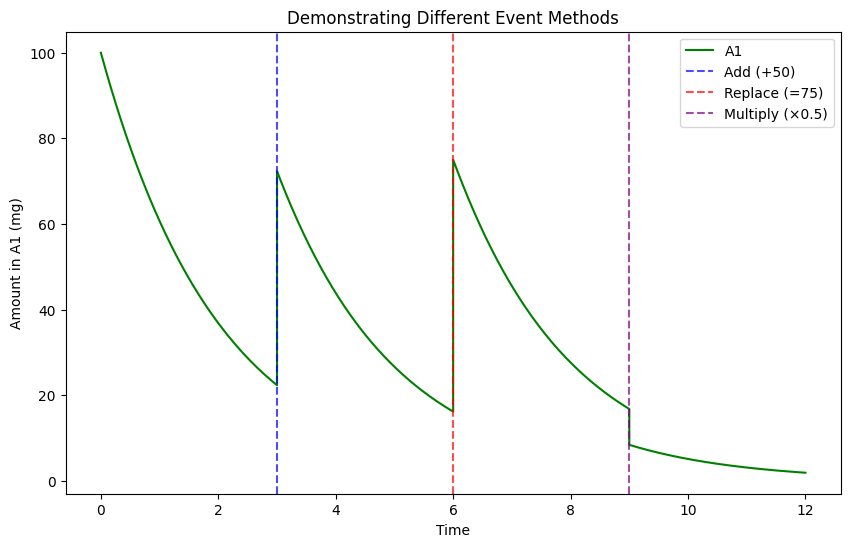

Event times:
[3.0, 6.0, 9.0]

Event methods:
['add', 'replace', 'multiply']

In [21]:
# Example 2: Using different event methods - replace and multiply
# This demonstrates the three different event methods

# Create another model instance  
scipy_model_methods = ScipyModel(model=filename)
scipy_model_methods.update_Y0(A1=100)  # Start with some amount in central compartment

# Demonstrate different event methods:
scipy_model_methods.add_event(time=3.0, state_var='A1', value=50.0, method='add')      # Add 50 mg
scipy_model_methods.add_event(time=6.0, state_var='A1', value=75.0, method='replace')  # Set to 75 mg  
scipy_model_methods.add_event(time=9.0, state_var='A1', value=0.5, method='multiply')  # Multiply by 0.5

# Run the model
times = np.linspace(0, 12, 1000)
solution_methods = scipy_model_methods.run_model(times)

# Plot the results
fig, ax = plt.subplots(figsize=(10, 6))
solution_methods.plot_results(variables='A1', ax=ax, color='green')
ax.set_title('Demonstrating Different Event Methods')
ax.axvline(x=3, color='blue', linestyle='--', alpha=0.7, label='Add (+50)')
ax.axvline(x=6, color='red', linestyle='--', alpha=0.7, label='Replace (=75)')
ax.axvline(x=9, color='purple', linestyle='--', alpha=0.7, label='Multiply (×0.5)')
ax.legend()
ax.set_ylabel('Amount in A1 (mg)')
plt.show()

print("Event times:", [event.time for event in scipy_model_methods.events])
print("Event methods:", [event.method for event in scipy_model_methods.events])

Number of events before clearing: 2

Events:
[(2.0, 'A0', 10.0, 'add'), (8.0, 'A0', 15.0, 'add')]

Number of events after clearing: 0

Number of events after adding one: 1

Event times between 0 and 10: [5.0]

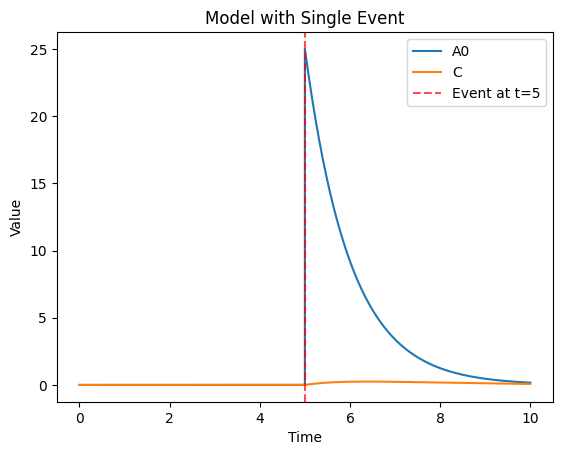

In [22]:
# Example 3: Clearing and managing events
# Show how to clear events and manage them

scipy_model_clear = ScipyModel(model=filename)
scipy_model_clear.update_constants(OralDose=30)

# Add some events
scipy_model_clear.add_event(time=2.0, state_var='A0', value=10, method='add')
scipy_model_clear.add_event(time=8.0, state_var='A0', value=15, method='add')

print(f"Number of events before clearing: {len(scipy_model_clear.events)}")
print("Events:", [(e.time, e.state_var, e.value, e.method) for e in scipy_model_clear.events])

# Clear all events
scipy_model_clear.clear_events()
print(f"Number of events after clearing: {len(scipy_model_clear.events)}")

# Add a single event
scipy_model_clear.add_event(time=5.0, state_var='A0', value=25, method='add')
print(f"Number of events after adding one: {len(scipy_model_clear.events)}")

# Get event times within a range
event_times = scipy_model_clear.get_event_times(0, 10)
print(f"Event times between 0 and 10: {event_times}")

# Run model
times = np.linspace(0, 10, 500)
solution_clear = scipy_model_clear.run_model(times)
solution_clear.plot_results(variables=['A0', 'C'])
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Event at t=5')
plt.legend()
plt.title('Model with Single Event')
plt.show()

In [23]:
jax_model_test = JaxModel(model=filename)
jax_model_test.add_event(time=5.0, state_var='A0', value=25.0, method='add')
times = np.linspace(0, 10, 100)
solution_jax = jax_model_test.run_model(times)

NotImplementedError: Discrete events are not yet supported for JAX-based models. Please use ScipyModel for models with discrete events, or consider implementing events as continuous forcing functions.

In [7]:
# Example 4: Trying to use events with JaxModel (will show error)
try:
    jax_model_test = JaxModel(model=filename)
    jax_model_test.add_event(time=5.0, state_var='A0', value=25.0, method='add')
    times = np.linspace(0, 10, 100)
    solution_jax = jax_model_test.run_model(times)
except NotImplementedError as e:
    print("Expected error when using events with JaxModel:")
    print(f"Error: {e}")
    print("\nFor models with discrete events, please use ScipyModel instead.")
    print("Alternatively, consider implementing discrete dosing as continuous forcing functions.")

Expected error when using events with JaxModel:

Error: Discrete events are not yet supported for JAX-based models. Please use ScipyModel for models with discrete 
events, or consider implementing events as continuous forcing functions.

For models with discrete events, please use ScipyModel instead.

Alternatively, consider implementing discrete dosing as continuous forcing functions.

## Summary: Discrete Events Implementation

I've successfully implemented discrete events functionality for PyMCSimMod that is similar to deSolve's event handling system. Here's what has been added:

### Key Features

1. **DiscreteEvent Class**: A Pydantic model that represents a discrete event with:
   - `time`: When the event occurs
   - `state_var`: Which state variable to modify
   - `value`: The value to use in the operation
   - `method`: The type of operation ('add', 'replace', 'multiply')

2. **Event Methods**: Three types of operations similar to deSolve:
   - **`add`**: Adds the value to the current state variable value
   - **`replace`**: Replaces the state variable value completely
   - **`multiply`**: Multiplies the current value by the given factor

3. **Model Integration**: Added to the base `OdeModel` class:
   - `add_event()`: Add a discrete event
   - `clear_events()`: Remove all events
   - `get_event_times()`: Get event times within a range
   - `apply_events_at_time()`: Apply events at a specific time

### Implementation Details

- **ScipyModel**: Full support with segment-wise integration between events
- **JaxModel**: Events are detected and throw an informative error (JAX has limitations with discrete operations)
- **Event Processing**: Events are automatically sorted by time and applied in order
- **Switch Times**: Event times are included in the ODE solver's switch detection system

### Usage Example

```python
# Create a model
model = ScipyModel('model.txt')

# Add discrete events
model.add_event(time=5.0, state_var='A0', value=25.0, method='add')
model.add_event(time=10.0, state_var='A1', value=50.0, method='replace') 
model.add_event(time=15.0, state_var='A0', value=0.5, method='multiply')

# Run simulation
times = np.linspace(0, 20, 1000)
solution = model.run_model(times)
```

This implementation provides the same conceptual functionality as deSolve's events but adapted for the PyMCSimMod framework!